# Return Probability Classifier — XGBoost

**Depends on:** `data/master_df_v2.parquet` — produced by `02_clustering.ipynb`  

**Outputs:**
- `data/master_df_v3.parquet` — master_df_v2 + `return_prob` + `return_flag`
- `outputs/return_clf_v1.pkl` — fitted model
- `outputs/return_classifier_metrics.json` — ROC-AUC, PR-AUC, Brier, threshold metrics
- `outputs/roc_pr_curves.png`
- `outputs/feature_importance.png`
- `outputs/return_prob_distribution.png`

---

All heavy logic lives in `src/return_classifier.py`. This notebook calls it, then focuses on evaluation visualisation.


In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)

Project root: Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, confusion_matrix,
)

from src.return_classifier import (
    build_features,
    train,
    evaluate,
    predict_proba,
    add_return_prob,
    save_model,
    save_metrics,
    CAT_COLS, NUM_COLS, TARGET, RETURN_PROB_THRESHOLD,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

DATA_DIR   = '../data'
OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports OK.')


Imports OK.


---
## 1. Load data


In [3]:
df = pd.read_parquet(f'{DATA_DIR}/master_df_v2.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')


Shape: (19207, 36)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon', 'price', 'freight_value', 'product_weight_g', 'n_items', 'product_id', 'product_category_name_english', 'seller_lat', 'seller_lon', 'seller_state', 'seller_city', 'seller_zip_code_prefix', 'review_score', 'payment_type', 'payment_value', 'delivery_days', 'days_late', 'order_value', 'is_return', 'return_rate_by_category', 'demand_per_zip', 'cust_seller_dist_km', 'dark_store_id']


---
## 2. Class imbalance check

Target is `is_return`. Expect ~3-5% positive rate.


In [4]:
pos_rate = df[TARGET].mean()
n_pos    = df[TARGET].sum()
n_neg    = len(df) - n_pos

print(f'Total rows    : {len(df):,}')
print(f'Positives (1) : {n_pos:,}  ({pos_rate*100:.2f}%)')
print(f'Negatives (0) : {n_neg:,}  ({(1-pos_rate)*100:.2f}%)')
print(f'Implied scale_pos_weight : {n_neg/n_pos:.1f}')
print()
print('Note: heavy imbalance — ROC-AUC alone is misleading.')
print('      PR-AUC is the primary evaluation metric.')

Total rows    : 19,207
Positives (1) : 565  (2.94%)
Negatives (0) : 18,642  (97.06%)
Implied scale_pos_weight : 33.0

Note: heavy imbalance — ROC-AUC alone is misleading.
      PR-AUC is the primary evaluation metric.


---
## 3. Feature matrix


In [5]:
X = build_features(df)
y = df[TARGET].astype(int)

print(f'X shape : {X.shape}')
print(f'Dtypes  :\n{X.dtypes}')
print()
X.describe().round(3)

X shape : (19207, 9)
Dtypes  :
product_category_name_english      int64
payment_type                       int64
customer_state                     int64
seller_state                       int64
review_score                     float64
days_late                        float64
freight_value                    float64
order_value                      float64
product_weight_g                 float64
dtype: object



,product_category_name_english,payment_type,customer_state,seller_state,review_score,days_late,freight_value,order_value,product_weight_g
count,19207.000,19207.000,19207.0,19207.000,19207.000,19207.000,19207.000,19207.000,19207.000
mean,39.734,0.936,0.0,17.197,4.166,-10.392,16.437,138.028,2164.601
std,22.558,0.697,0.0,3.853,1.294,8.069,13.990,184.739,4600.193
min,0.000,0.000,0.0,0.000,1.000,-83.000,0.000,0.000,0.000
25%,15.000,1.000,0.0,19.000,4.000,-15.000,9.085,52.325,300.000
50%,43.000,1.000,0.0,19.000,5.000,-10.000,13.250,90.850,675.000
75%,64.000,1.000,0.0,19.000,5.000,-6.000,17.290,157.300,1800.000
max,70.000,4.000,0.0,20.000,5.000,161.000,354.760,4513.320,184400.000


---
## 4. Train

XGBClassifier with `scale_pos_weight` auto-computed from training split.  
Wrapped in `CalibratedClassifierCV(method='sigmoid', cv=3)` for probability calibration.


In [6]:
model, X_test, y_test = train(df)
print(f'Test set: {len(X_test):,} rows | positives: {y_test.sum():,}')

[train] Train: 15,365 rows | positives: 452 (2.9%) | scale_pos_weight: 33.0
[train] Model fitted.
Test set: 3,842 rows | positives: 113


---
## 5. Evaluate


In [7]:
metrics = evaluate(model, X_test, y_test)
print()
print(json.dumps(metrics, indent=2))

[evaluate] ROC-AUC : 0.9982  (✓ target met)
[evaluate] PR-AUC  : 0.9539
[evaluate] Brier   : 0.0063
[evaluate] @ threshold 0.3 — precision=0.8291  recall=0.8584  f1=0.8435  flagged=3.05% of orders

{
  "roc_auc": 0.9982,
  "pr_auc": 0.9539,
  "brier_score": 0.0063,
  "n_test": 3842,
  "n_positives_test": 113,
  "threshold_0.3": {
    "precision": 0.8291,
    "recall": 0.8584,
    "f1": 0.8435,
    "flagged_pct": 3.05
  }
}


---
## 6. ROC curve + Precision-Recall curve


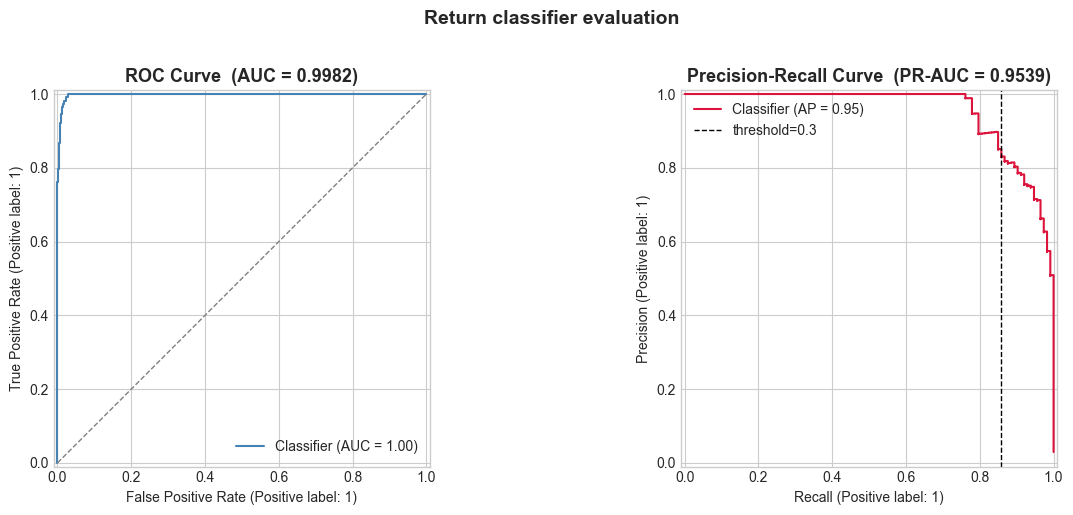

Saved → outputs/roc_pr_curves.png


In [8]:
y_prob = model.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax1, color='steelblue')
ax1.plot([0,1],[0,1],'--',color='grey',linewidth=1)
ax1.set_title(f"ROC Curve  (AUC = {metrics['roc_auc']})", fontsize=13, fontweight='bold')

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax2, color='crimson')
ax2.axvline(metrics[f'threshold_{RETURN_PROB_THRESHOLD}']['recall'],
            color='black', linestyle='--', linewidth=1,
            label=f'threshold={RETURN_PROB_THRESHOLD}')
ax2.set_title(f"Precision-Recall Curve  (PR-AUC = {metrics['pr_auc']})",
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Return classifier evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/roc_pr_curves.png')

---
## 7. Confusion matrix @ threshold 0.30


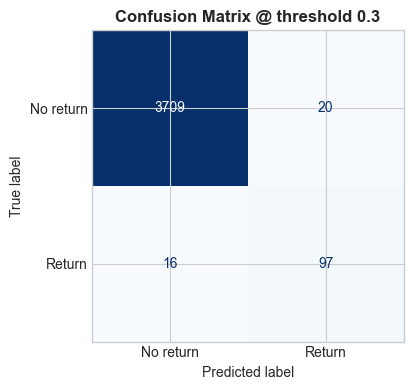

Saved → outputs/confusion_matrix.png


In [9]:
y_pred = (y_prob >= RETURN_PROB_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No return','Return']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix @ threshold {RETURN_PROB_THRESHOLD}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/confusion_matrix.png')

---
## 8. Feature importance

Using XGBoost's built-in `feature_importances_` (gain-based).  
The calibrator wraps the base estimator — we access it via `.calibrated_classifiers_`.


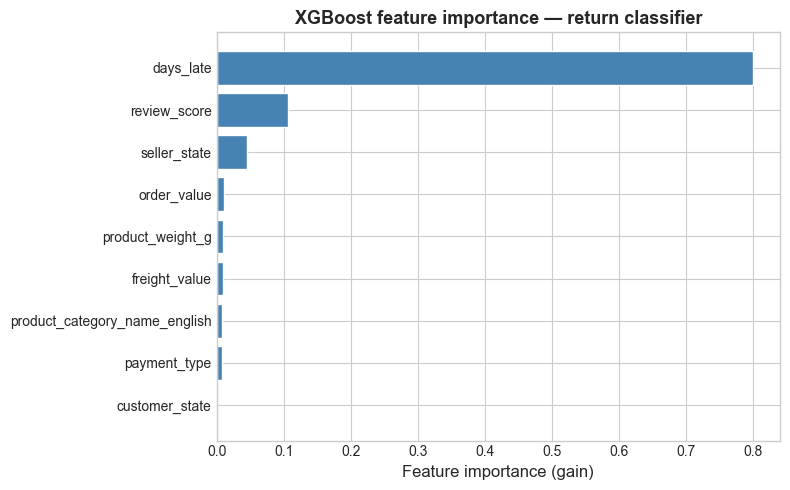

Saved → outputs/feature_importance.png

                      feature  importance
                    days_late    0.800006
                 review_score    0.107072
                 seller_state    0.045941
                  order_value    0.011703
             product_weight_g    0.009103
                freight_value    0.009071
product_category_name_english    0.008629
                 payment_type    0.008475
               customer_state    0.000000


In [10]:
feature_names = CAT_COLS + NUM_COLS

# Average importances across the 3 CV folds in CalibratedClassifierCV
importances = np.mean(
    [clf.estimator.feature_importances_
     for clf in model.calibrated_classifiers_],
    axis=0,
)
imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Feature importance (gain)', fontsize=12)
ax.set_title('XGBoost feature importance — return classifier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/feature_importance.png')
print()
print(imp_df.sort_values('importance', ascending=False).to_string(index=False))


---
## 9. Return probability distribution


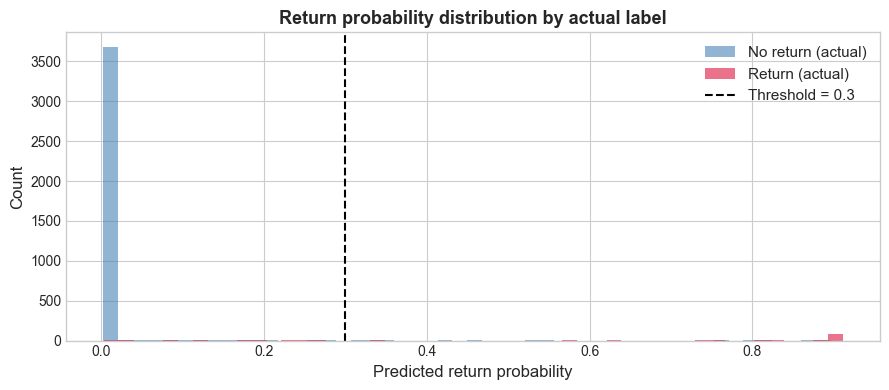

Saved → outputs/return_prob_distribution.png


In [11]:
return_probs = model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(return_probs[y_test == 0], bins=50, alpha=0.6,
        color='steelblue', label='No return (actual)')
ax.hist(return_probs[y_test == 1], bins=50, alpha=0.6,
        color='crimson', label='Return (actual)')
ax.axvline(RETURN_PROB_THRESHOLD, color='black', linestyle='--',
           linewidth=1.5, label=f'Threshold = {RETURN_PROB_THRESHOLD}')
ax.set_xlabel('Predicted return probability', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Return probability distribution by actual label',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/return_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/return_prob_distribution.png')

---
## 10. Add return_prob to master_df → save as master_df_v3

`return_flag = 1` where `return_prob >= 0.30`.  
These orders are pre-assigned pickup slots in the SDVRP (Vybhav → Pritam Day 4 handoff).


In [12]:
df_v3 = add_return_prob(model, df)

print(f'\nreturn_prob stats:')
print(df_v3['return_prob'].describe().round(4))
print(f'\nreturn_flag distribution:')
print(df_v3['return_flag'].value_counts())

[add_return_prob] return_prob added | 593 orders flagged for pickup (3.1% at threshold 0.3)

return_prob stats:
count    19207.0000
mean         0.0300
std          0.1472
min          0.0031
25%          0.0031
50%          0.0031
75%          0.0031
max          0.9113
Name: return_prob, dtype: float64

return_flag distribution:
return_flag
0    18614
1      593
Name: count, dtype: int64


---
## 11. Save all outputs


In [13]:
# master_df_v3
df_v3.to_parquet(f'{DATA_DIR}/master_df_v3.parquet', index=False)
print(f'data/master_df_v3.parquet  ({len(df_v3):,} rows, {df_v3.shape[1]} cols)')

# model
save_model(model, path=f'{OUTPUT_DIR}/return_clf_v1.pkl')

# metrics
save_metrics(metrics, path=f'{OUTPUT_DIR}/return_classifier_metrics.json')

data/master_df_v3.parquet  (19,207 rows, 38 cols)
[save_model] Model saved → ../outputs/return_clf_v1.pkl
[save_metrics] Metrics saved → ../outputs/return_classifier_metrics.json


---
## Deliverables checklist

| Output | Status |
|--------|--------|
| `data/master_df_v3.parquet` (with `return_prob`, `return_flag`) | ✅ |
| `outputs/return_clf_v1.pkl` | ✅ |
| `outputs/return_classifier_metrics.json` | ✅ |
| `outputs/roc_pr_curves.png` | ✅ |
| `outputs/confusion_matrix.png` | ✅ |
| `outputs/feature_importance.png` | ✅ |
| `outputs/return_prob_distribution.png` | ✅ |

**Handoffs:**
- `master_df_v3.parquet` → **Pritam** (SDVRP: `return_flag=1` orders get pickup slots)
- `feature_importance.png` → **Varsha** (report slide)
- `return_classifier_metrics.json` → **Pranav** (RESULTS.md)
